# Fixing clear-sky plots for the paper

I'm not sure what happened, but the clr_sky_plots_4paper.ipynb no longer works. Many of the things it references no longer exist. Because there was an error in the plot of clear-sky observations as a time of day (12 and 15 UTC are the same plot), I need to try an alternate approach to reconstruct the plot from my (philipp's) data

# Issues with OmB differences
We see a large error when OmB is binned by angle for the highest values, but these values are not visible in the plots. Will need to revisit this, and this is complicated, because I do not quite understand how Sandy saved her output


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr
import seaborn as sns

In [3]:
sns.set_style('dark')

In [4]:
from mpl_toolkits.basemap import Basemap

In [5]:
# Importing the observations data
ds_obs     = xr.open_dataset('/perm/kipg/RTTOV_related/PG_datasets/vis_202308_obs.nc')
# And splitting them into the times of day
ds_06 = ds_obs.sel(time=ds_obs.time.dt.hour==6)
ds_09 = ds_obs.sel(time=ds_obs.time.dt.hour==9)
ds_12 = ds_obs.sel(time=ds_obs.time.dt.hour==12)
ds_15 = ds_obs.sel(time=ds_obs.time.dt.hour==15)

In [5]:
# ## Setting the projection for everything

# central_lon=13.8
# central_lat=47.4
# globe = ccrs.Globe(ellipse='sphere', semimajor_axis=6371200)
# proj = ccrs.LambertConformal(central_latitude = central_lat, 
#                              central_longitude = central_lon, 
#                              standard_parallels = (43, 57),
#                              globe=globe,
#                              false_easting=375000.0, 
#                              false_northing=528000.0)

In [6]:
# Getting the minimum values at each pixel.

cs_06=np.nanmin(ds_06.obs_ch01_seviri.data,axis=0)
cs_09=np.nanmin(ds_09.obs_ch01_seviri.data,axis=0)
cs_12=np.nanmin(ds_12.obs_ch01_seviri.data,axis=0)
cs_15=np.nanmin(ds_15.obs_ch01_seviri.data,axis=0)




/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/4139081327.py:3: RuntimeWarning: All-NaN slice encountered
  cs_06=np.nanmin(ds_06.obs_ch01_seviri.data,axis=0)
/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/4139081327.py:4: RuntimeWarning: All-NaN slice encountered
  cs_09=np.nanmin(ds_09.obs_ch01_seviri.data,axis=0)
/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/4139081327.py:5: RuntimeWarning: All-NaN slice encountered
  cs_12=np.nanmin(ds_12.obs_ch01_seviri.data,axis=0)
/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/4139081327.py:6: RuntimeWarning: All-NaN slice encountered
  cs_15=np.nanmin(ds_15.obs_ch01_seviri.data,axis=0)


In [7]:
tmp = np.nan_to_num(ds_06.obs_ch01_seviri.data,nan=1000)
cs_06_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_09.obs_ch01_seviri.data,nan=1000)
cs_09_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_12.obs_ch01_seviri.data,nan=1000)
cs_12_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_15.obs_ch01_seviri.data,nan=1000)
cs_15_index=np.nanargmin(tmp,axis=0)


In [8]:

def geo_map_vis(data_list, labels, cmaps,
                lon, lat,
                date, unit,
                vmin, vmax, shrink,
                log=False,
                save=False,
                font=14,
                axes=None, fig=None):
    """
    Plot 1–4 panels of geographic data on Basemap, with a shared colorbar
    that honors your vmin/vmax and colormap even when you pass in axes.
    """
    n = len(data_list)
    if not (1 <= n <= 4):
        raise ValueError("data_list must have between 1 and 4 elements")

    # 1) decide whether we created the figure & axes or were given them
    if axes is None:
        # standalone: build own fig & axes
        if n == 1:
            nrows, ncols, figsize = 1, 1, (6, 5)
        elif n == 2:
            nrows, ncols, figsize = 1, 2, (12, 5)
        elif n == 3:
            nrows, ncols, figsize = 1, 3, (15, 12)
        else:
            nrows, ncols, figsize = 1, 4, (20, 12)

        fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
        fig.set_facecolor('white')
        plt.rcParams.update({'font.size': font})
        fig.subplots_adjust(wspace=0.01, hspace=0.0)
        # flatten
        axs_flat = axs.flatten().tolist() if n>1 else [axs]
        standalone = True
    else:
        # using user-supplied axes
        axs_flat = axes
        fig = fig or plt.gcf()
        standalone = False

    # 2) normalization & tick locations
    if log:
        vmin = max(vmin, 1e-10)
        norm = LogNorm(vmin=vmin, vmax=vmax)
        ticks = np.logspace(np.log10(vmin), np.log10(vmax), 5)
    else:
        norm = None
        step = 0.25 * (vmax - vmin)
        ticks = np.arange(vmin, vmax + step, step)

    # map bounds
    lon0, lat0 = 13.8, 47.4
    llon, ulon = lon0 - 8.8, lon0 + 10.0
    llat, ulat = lat0 - 4.4, lat0 + 3.4

    # 3) plot each panel
    for idx, (data, title, cmap) in enumerate(zip(data_list, labels, cmaps)):
        ax = axs_flat[idx]
        m = Basemap(projection='lcc',
                    lon_0=lon0, lat_0=lat0,
                    llcrnrlon=llon, llcrnrlat=llat,
                    urcrnrlon=ulon, urcrnrlat=ulat,
                    resolution='h', ax=ax)
        m.drawcountries(); m.drawcoastlines()
        x, y = m(lon, lat)
        p = m.pcolormesh(x, y, data,
                         shading='nearest',
                         cmap=cmap,
                         vmin=vmin, vmax=vmax,
                         norm=norm)
        ax.set_title(f"{title} {date}", fontsize=font)

        parallels = np.arange(llat+1, ulat, 3)
        if idx == 0:
            m.drawparallels(parallels, labels=[1,0,0,0], fontsize=font-2)
        else:
            m.drawparallels(parallels, labels=[0,0,0,0], fontsize=font-2)

        meridians = np.arange(llon+1, ulon, 5)
        m.drawmeridians(meridians, labels=[0,0,0,1], fontsize=font-2)

        if idx > 0:
            ax.yaxis.set_visible(False)
            ax.spines['left'].set_visible(False)
        ax.set_facecolor('yellow')
    # 4) ALWAYS add the shared colorbar, even if axes were passed in
    cbar = fig.colorbar(p,
                        ax=axs_flat[:n],
                        orientation='vertical',
                        pad=0.005,
                        shrink=shrink)
    cbar.set_label(unit, fontsize=font)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
    cbar.ax.tick_params(labelsize=font)
    return fig, axs

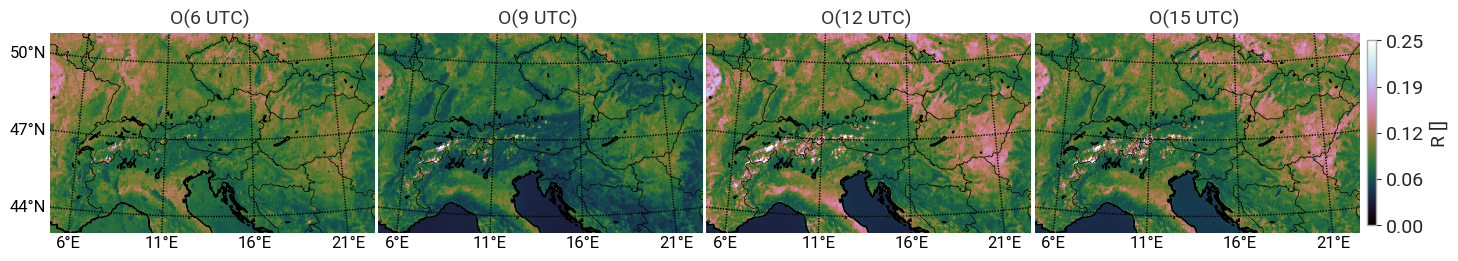

In [9]:

fig,axs = geo_map_vis([cs_06, cs_09, cs_12, cs_15], ["O(6 UTC)", "O(9 UTC)", "O(12 UTC)", "O(15 UTC)"], cmaps=["cubehelix", "cubehelix","cubehelix", "cubehelix"],
            date="", unit="R []",
            lon=ds_obs.lon.values, lat=ds_obs.lat.values,
            vmin=0.0, vmax=0.25,save=True,shrink=0.2
            )

In [10]:
# fig.savefig('../../figs/20260211-fix-O-UTC.png',bbox_inches='tight',dpi=300)

# For the OmB differences I need to manage to also load Sandy's simulations, lets hope this isn't to difficult 

In [7]:
ds_v12=xr.load_dataset('/home/kipg/perm/RTTOV_related/experiment_results/rttov_v122_A_1.nc')

In [8]:
cs_v12  = ds_v12.synthetic_reflectance_VIS006[:,:,:,1].data
sza_v12 = ds_v12.SZA[:,:,:].data
dates=ds_v12.datetimes

In [9]:
indices = np.where(np.char.startswith(dates.astype(str), '06', start=9))[0]
cs_v12_06   =  cs_v12[indices,:,:]
sza_v12_06  = sza_v12[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '09', start=9))[0]
cs_v12_09   = cs_v12[indices,:,:]
sza_v12_09  = sza_v12[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '12', start=9))[0]
cs_v12_12   = cs_v12[indices,:,:]
sza_v12_12  = sza_v12[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '15', start=9))[0]
cs_v12_15   = cs_v12[indices,:,:]
sza_v12_15  = sza_v12[indices,:,:]

In [10]:
ds_v13=xr.load_dataset('/home/kipg/perm/RTTOV_related/experiment_results/rttov_v132_A_1.nc')

In [11]:
cs_v13  = ds_v13.synthetic_reflectance_VIS006[:,:,:,1].data

In [12]:
indices = np.where(np.char.startswith(dates.astype(str), '06', start=9))[0]
cs_v13_06   =  cs_v13[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '09', start=9))[0]
cs_v13_09   = cs_v13[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '12', start=9))[0]
cs_v13_12   = cs_v13[indices,:,:]
indices = np.where(np.char.startswith(dates.astype(str), '15', start=9))[0]
cs_v13_15   = cs_v13[indices,:,:]

# Now I need to get the indexes when the minimal observation occured

In [13]:
tmp = np.nan_to_num(ds_06.obs_ch01_seviri.data,nan=1000)
cs_06_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_09.obs_ch01_seviri.data,nan=1000)
cs_09_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_12.obs_ch01_seviri.data,nan=1000)
cs_12_index=np.nanargmin(tmp,axis=0)
tmp = np.nan_to_num(ds_15.obs_ch01_seviri.data,nan=1000)
cs_15_index=np.nanargmin(tmp,axis=0)


/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/I

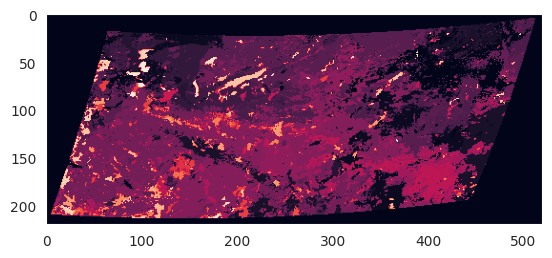

In [14]:
plt.imshow(cs_06_index)

### And now the values from the background

In [15]:
cs_3D = cs_v12_06
y_idx, z_idx = np.ogrid[:cs_3D.shape[1], :cs_3D.shape[2]]

index_2D = cs_06_index
cs_3D    = cs_v12_06
cs_v12_06_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
cs_3D    = cs_v13_06
cs_v13_06_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
sza_06   =  sza_v12_06[index_2D, y_idx, z_idx]  

index_2D = cs_09_index
cs_3D    = cs_v12_09
cs_v12_09_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
cs_3D    = cs_v13_09
cs_v13_09_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
sza_09   =  sza_v12_09[index_2D, y_idx, z_idx]  

index_2D = cs_12_index
cs_3D    = cs_v12_12
cs_v12_12_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
cs_3D    = cs_v13_12
cs_v13_12_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
sza_12   =  sza_v12_12[index_2D, y_idx, z_idx]  

index_2D = cs_15_index
cs_3D    = cs_v12_15
cs_v12_15_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
cs_3D    = cs_v13_15
cs_v13_15_min = cs_3D[index_2D, y_idx, z_idx]  # shape (y, z)
sza_15   =  sza_v12_15[index_2D, y_idx, z_idx]  


## Now to resulve the mystery of the huge differences for high sza, I can't find anything!

#### There are some low sza values that I assume must arise from interpolation at the edges. To avoid this I'll make any of the OmB which are next to a nan also a nan, which should cut out one line around the edge

In [16]:
def func_nan_edge(field):
    nan_mask = np.isnan(field)
    
    # Check all 4 directions
    neighbors_are_nan = (
        np.pad(nan_mask[:-1, :], ((1,0),(0,0)), constant_values=False) |  # up
        np.pad(nan_mask[1:, :], ((0,1),(0,0)), constant_values=False) |   # down
        np.pad(nan_mask[:, :-1], ((0,0),(1,0)), constant_values=False) |  # left
        np.pad(nan_mask[:, 1:], ((0,0),(0,1)), constant_values=False)     # right
    )
    
    field[neighbors_are_nan | nan_mask] = np.nan
    return field

# Ok, got to bin this myself

In [17]:
sza_bin_edges = np.linspace(0,90,37)
sza_bin_mean = sza_bin_edges[:-1]/2+sza_bin_edges[1:]/2
bin_indices = np.digitize(sza_06.ravel(),sza_bin_edges)
OmB_v12 = cs_06 - cs_v12_06_min
OmB_v12_edge = func_nan_edge(OmB_v12)

OmB_v12_binned_by_sza = [np.nanmean(OmB_v12.ravel()[bin_indices == i]) if np.any(bin_indices == i) else np.nan 
             for i in range(1, len(sza_bin_edges))]


/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/1754856970.py:7: RuntimeWarning: Mean of empty slice
  OmB_v12_binned_by_sza = [np.nanmean(OmB_v12.ravel()[bin_indices == i]) if np.any(bin_indices == i) else np.nan


In [24]:
np.nanmax(sza_06)

81.52722276201061

In [18]:
def func_bin_by_sza(cs_o,cs_b,sza,min_count=50):
    
    sza_bin_edges = np.linspace(0,90,19+9)
    sza_bin_mean = sza_bin_edges[:-1]/2+sza_bin_edges[1:]/2
    bin_indices = np.digitize(sza.ravel(),sza_bin_edges)
    OmB = cs_o - cs_b
    #Removing edges to avoid interpolate sza issue
    OmB_edge = func_nan_edge(OmB)
    
    # OmB_mean = [np.nanmean(OmB_edge.ravel()[bin_indices == i]) if np.any(bin_indices == i) else np.nan 
                 # for i in range(1, len(sza_bin_edges))]
    # OmB_std  = [np.nanstd(OmB_edge.ravel()[bin_indices == i]) if np.any(bin_indices == i) else np.nan 
                 # for i in range(1, len(sza_bin_edges))]
    # len(bin_indices[bin_indices==20])
    OmB_mean = [np.nanmean(OmB_edge.ravel()[bin_indices == i]) if len(bin_indices[bin_indices==i])>min_count else np.nan 
                 for i in range(1, len(sza_bin_edges))]
    OmB_std  = [np.nanstd(OmB_edge.ravel()[bin_indices == i])  if len(bin_indices[bin_indices==i])>min_count else np.nan 
                 for i in range(1, len(sza_bin_edges))]
    
    return sza_bin_mean,OmB_mean, OmB_std

In [19]:
sza_bin_mean, OmB_mean_v12_06_sza, OmB_std_v12_06_sza = func_bin_by_sza(cs_06,cs_v12_06_min,sza_06)
sza_bin_mean, OmB_mean_v12_09_sza, OmB_std_v12_09_sza = func_bin_by_sza(cs_09,cs_v12_09_min,sza_09)
sza_bin_mean, OmB_mean_v12_12_sza, OmB_std_v12_12_sza = func_bin_by_sza(cs_12,cs_v12_12_min,sza_12)
sza_bin_mean, OmB_mean_v12_15_sza, OmB_std_v12_15_sza = func_bin_by_sza(cs_15,cs_v12_15_min,sza_15)
sza_bin_mean, OmB_mean_v13_06_sza, OmB_std_v13_06_sza = func_bin_by_sza(cs_06,cs_v13_06_min,sza_06)
sza_bin_mean, OmB_mean_v13_09_sza, OmB_std_v13_09_sza = func_bin_by_sza(cs_09,cs_v13_09_min,sza_09)
sza_bin_mean, OmB_mean_v13_12_sza, OmB_std_v13_12_sza = func_bin_by_sza(cs_12,cs_v13_12_min,sza_12)
sza_bin_mean, OmB_mean_v13_15_sza, OmB_std_v13_15_sza = func_bin_by_sza(cs_15,cs_v13_15_min,sza_15)


/etc/ecmwf/ssd/ssd1/jupyterhub/km4c-jupyterhub/tmpdirs/km4c.38029436/ipykernel_2918515/1100908671.py:15: RuntimeWarning: Mean of empty slice
  OmB_mean = [np.nanmean(OmB_edge.ravel()[bin_indices == i]) if len(bin_indices[bin_indices==i])>min_count else np.nan
/usr/local/apps/python3/3.11.10-01/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [20]:
sza_bin_mean

array([ 1.66666667,  5.        ,  8.33333333, 11.66666667, 15.        ,
       18.33333333, 21.66666667, 25.        , 28.33333333, 31.66666667,
       35.        , 38.33333333, 41.66666667, 45.        , 48.33333333,
       51.66666667, 55.        , 58.33333333, 61.66666667, 65.        ,
       68.33333333, 71.66666667, 75.        , 78.33333333, 81.66666667,
       85.        , 88.33333333])

In [21]:
OmB_mean_v12_06_sza

[nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 0.011039158853675499,
 0.01353810463323773,
 0.013421706562795989,
 0.012885637083417858,
 0.014104428753318049,
 0.012282180844033836,
 -0.00512539456001571,
 nan,
 nan]

(20.0, 90.0)

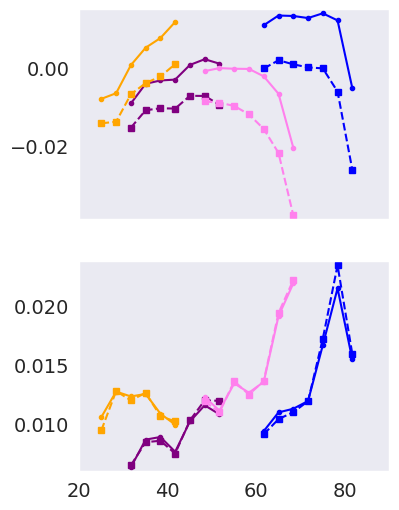

In [73]:
fig, axs = plt.subplots(2,1,figsize=(4,6),sharex=True)
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
axs[0].plot(sza_bin_mean,OmB_mean_v12_06_sza,marker='.',color=set_colors[0])
axs[0].plot(sza_bin_mean,OmB_mean_v13_06_sza,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[0].plot(sza_bin_mean,OmB_mean_v12_09_sza,marker='.',color=set_colors[1])
axs[0].plot(sza_bin_mean,OmB_mean_v13_09_sza,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[0].plot(sza_bin_mean,OmB_mean_v12_12_sza,marker='.',color=set_colors[2])
axs[0].plot(sza_bin_mean,OmB_mean_v13_12_sza,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[0].plot(sza_bin_mean,OmB_mean_v12_15_sza,marker='.',color=set_colors[3])
axs[0].plot(sza_bin_mean,OmB_mean_v13_15_sza,marker='s',color=set_colors[3],linestyle='--',markersize=5)

axs[1].plot(sza_bin_mean,OmB_std_v12_06_sza,marker='.',color=set_colors[0])
axs[1].plot(sza_bin_mean,OmB_std_v13_06_sza,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[1].plot(sza_bin_mean,OmB_std_v12_09_sza,marker='.',color=set_colors[1])
axs[1].plot(sza_bin_mean,OmB_std_v13_09_sza,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[1].plot(sza_bin_mean,OmB_std_v12_12_sza,marker='.',color=set_colors[2])
axs[1].plot(sza_bin_mean,OmB_std_v13_12_sza,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[1].plot(sza_bin_mean,OmB_std_v12_15_sza,marker='.',color=set_colors[3])
axs[1].plot(sza_bin_mean,OmB_std_v13_15_sza,marker='s',color=set_colors[3],linestyle='--',markersize=5)

# plt.ylim(-0.2,0.1)
plt.xlim(20,90)

(-0.1, 0.1)

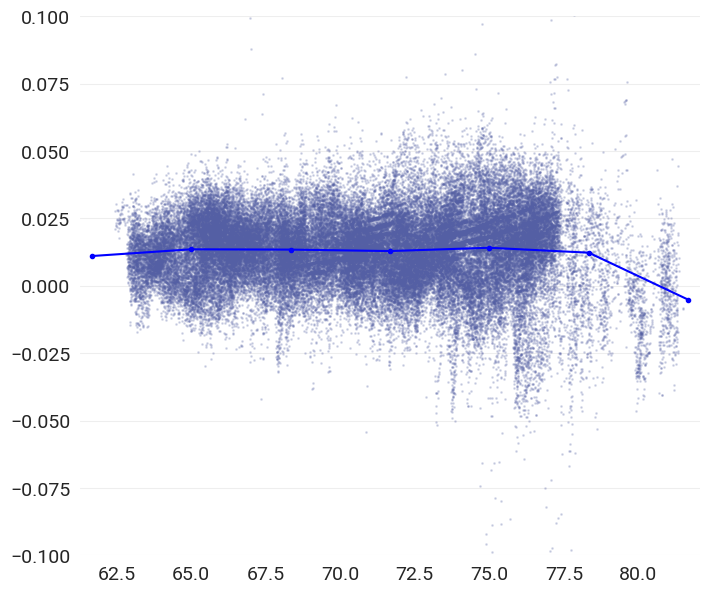

In [47]:
OmB_v12_edge = func_nan_edge(cs_06-cs_v12_06_min)
plt.scatter(sza_06.ravel(),OmB_v12_edge,s=1,alpha=0.2)
plt.plot(sza_bin_mean,OmB_mean_v12_06_sza,marker='.',color=set_colors[0])
plt.ylim(-0.1,0.1)

(-0.1, 0.1)

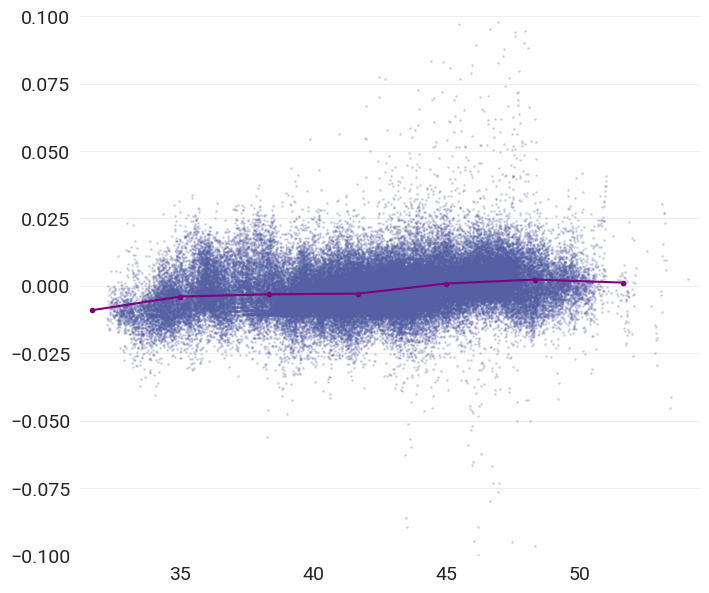

In [48]:
OmB_v12_edge = func_nan_edge(cs_09-cs_v12_09_min)
plt.scatter(sza_09.ravel(),OmB_v12_edge,s=1,alpha=0.2)
plt.plot(sza_bin_mean,OmB_mean_v12_09_sza,marker='.',color=set_colors[1])
plt.ylim(-0.1,0.1)

(-0.1, 0.1)

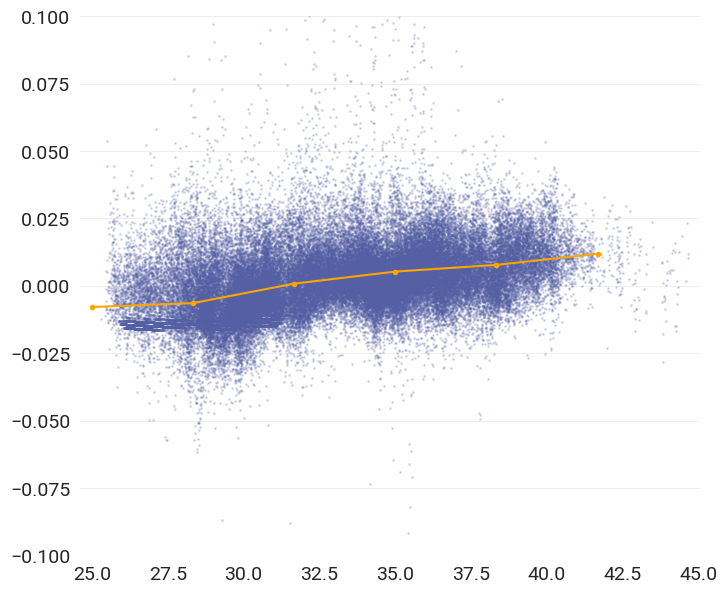

In [49]:
OmB_v12_edge = func_nan_edge(cs_12-cs_v12_12_min)
plt.scatter(sza_12.ravel(),OmB_v12_edge,s=1,alpha=0.2)
plt.plot(sza_bin_mean,OmB_mean_v12_12_sza,marker='.',color=set_colors[2])
plt.ylim(-0.1,0.1)

# Ok, got to look at terrain

It's crazy, but I'll load the default output to get the data

In [51]:
ds_mod     = xr.open_dataset('/perm/kipg/RTTOV_related/PG_datasets/vis_202308_default_settings_obsgrid.nc')


In [60]:
z= ds_mod.z_surface.data[0,:,:]/1000 # in km

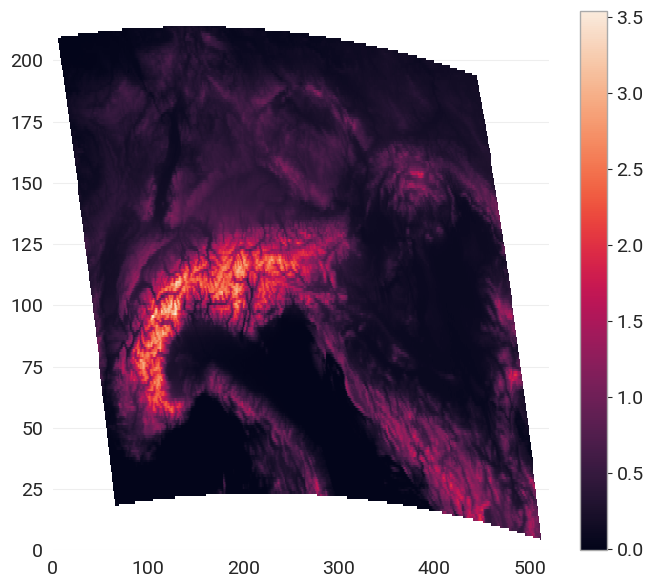

In [61]:
plt.pcolormesh(z)
plt.colorbar()

In [68]:
def func_bin_by_z(cs_o,cs_b,z,min_count=50):
    
    bin_edges = np.linspace(0,4,17)
    bin_mean = bin_edges[:-1]/2+bin_edges[1:]/2
    bin_indices = np.digitize(z.ravel(),bin_edges)
    OmB = cs_o - cs_b
    #Removing edges to avoid interpolate sza issue
    OmB_edge = func_nan_edge(OmB)
    
    OmB_mean = [np.nanmean(OmB_edge.ravel()[bin_indices == i]) if len(bin_indices[bin_indices==i])>min_count else np.nan 
                 for i in range(1, len(bin_edges))]
    OmB_std  = [np.nanstd(OmB_edge.ravel()[bin_indices == i])  if len(bin_indices[bin_indices==i])>min_count else np.nan 
                 for i in range(1, len(bin_edges))]
    
    return bin_mean,OmB_mean, OmB_std

In [69]:
z_bin_mean, OmB_mean_v12_06_z, OmB_std_v12_06_z = func_bin_by_z(cs_06,cs_v12_06_min,z)
z_bin_mean, OmB_mean_v12_09_z, OmB_std_v12_09_z = func_bin_by_z(cs_09,cs_v12_09_min,z)
z_bin_mean, OmB_mean_v12_12_z, OmB_std_v12_12_z = func_bin_by_z(cs_12,cs_v12_12_min,z)
z_bin_mean, OmB_mean_v12_15_z, OmB_std_v12_15_z = func_bin_by_z(cs_15,cs_v12_15_min,z)
z_bin_mean, OmB_mean_v13_06_z, OmB_std_v13_06_z = func_bin_by_z(cs_06,cs_v13_06_min,z)
z_bin_mean, OmB_mean_v13_09_z, OmB_std_v13_09_z = func_bin_by_z(cs_09,cs_v13_09_min,z)
z_bin_mean, OmB_mean_v13_12_z, OmB_std_v13_12_z = func_bin_by_z(cs_12,cs_v13_12_min,z)
z_bin_mean, OmB_mean_v13_15_z, OmB_std_v13_15_z = func_bin_by_z(cs_15,cs_v13_15_min,z)


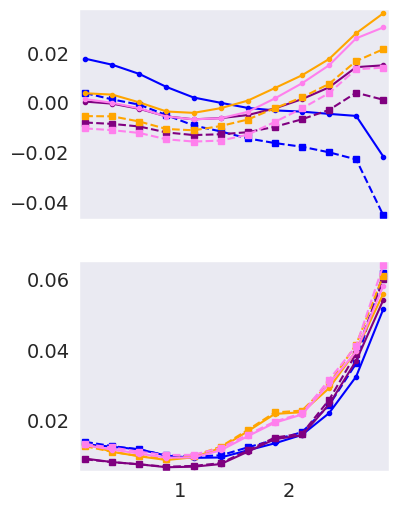

In [72]:
fig, axs = plt.subplots(2,1,figsize=(4,6),sharex=True)
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
axs[0].plot(z_bin_mean,OmB_mean_v12_06_z,marker='.',color=set_colors[0])
axs[0].plot(z_bin_mean,OmB_mean_v13_06_z,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[0].plot(z_bin_mean,OmB_mean_v12_09_z,marker='.',color=set_colors[1])
axs[0].plot(z_bin_mean,OmB_mean_v13_09_z,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[0].plot(z_bin_mean,OmB_mean_v12_12_z,marker='.',color=set_colors[2])
axs[0].plot(z_bin_mean,OmB_mean_v13_12_z,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[0].plot(z_bin_mean,OmB_mean_v12_15_z,marker='.',color=set_colors[3])
axs[0].plot(z_bin_mean,OmB_mean_v13_15_z,marker='s',color=set_colors[3],linestyle='--',markersize=5)

axs[1].plot(z_bin_mean,OmB_std_v12_06_z,marker='.',color=set_colors[0])
axs[1].plot(z_bin_mean,OmB_std_v13_06_z,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[1].plot(z_bin_mean,OmB_std_v12_09_z,marker='.',color=set_colors[1])
axs[1].plot(z_bin_mean,OmB_std_v13_09_z,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[1].plot(z_bin_mean,OmB_std_v12_12_z,marker='.',color=set_colors[2])
axs[1].plot(z_bin_mean,OmB_std_v13_12_z,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[1].plot(z_bin_mean,OmB_std_v12_15_z,marker='.',color=set_colors[3])
axs[1].plot(z_bin_mean,OmB_std_v13_15_z,marker='s',color=set_colors[3],linestyle='--',markersize=5)


# Now putting it together

(0.0, 3.0)

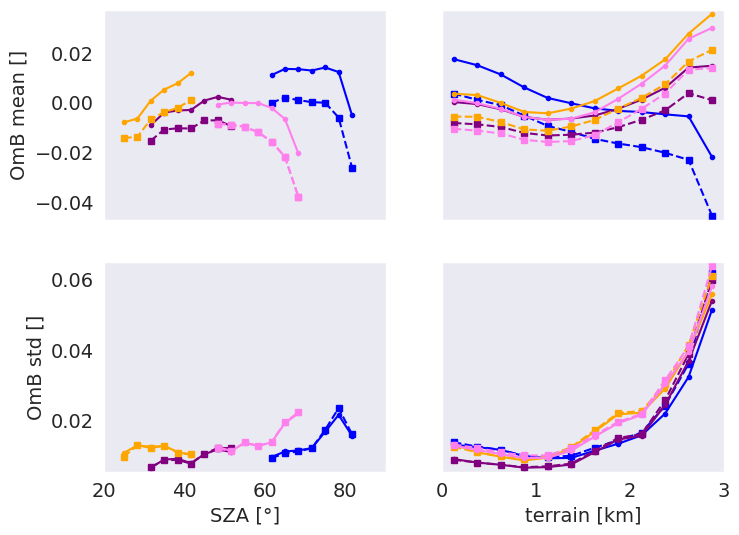

In [82]:
fig, axs = plt.subplots(2,2,figsize=(8,6),sharex='col',sharey='row')
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
axs[0,0].plot(sza_bin_mean,OmB_mean_v12_06_sza,marker='.',color=set_colors[0])
axs[0,0].plot(sza_bin_mean,OmB_mean_v13_06_sza,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[0,0].plot(sza_bin_mean,OmB_mean_v12_09_sza,marker='.',color=set_colors[1])
axs[0,0].plot(sza_bin_mean,OmB_mean_v13_09_sza,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[0,0].plot(sza_bin_mean,OmB_mean_v12_12_sza,marker='.',color=set_colors[2])
axs[0,0].plot(sza_bin_mean,OmB_mean_v13_12_sza,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[0,0].plot(sza_bin_mean,OmB_mean_v12_15_sza,marker='.',color=set_colors[3])
axs[0,0].plot(sza_bin_mean,OmB_mean_v13_15_sza,marker='s',color=set_colors[3],linestyle='--',markersize=5)
axs[1,0].plot(sza_bin_mean,OmB_std_v12_06_sza,marker='.',color=set_colors[0])
axs[1,0].plot(sza_bin_mean,OmB_std_v13_06_sza,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[1,0].plot(sza_bin_mean,OmB_std_v12_09_sza,marker='.',color=set_colors[1])
axs[1,0].plot(sza_bin_mean,OmB_std_v13_09_sza,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[1,0].plot(sza_bin_mean,OmB_std_v12_12_sza,marker='.',color=set_colors[2])
axs[1,0].plot(sza_bin_mean,OmB_std_v13_12_sza,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[1,0].plot(sza_bin_mean,OmB_std_v12_15_sza,marker='.',color=set_colors[3])
axs[1,0].plot(sza_bin_mean,OmB_std_v13_15_sza,marker='s',color=set_colors[3],linestyle='--',markersize=5)

axs[0,0].plot(sza_bin_mean,OmB_mean_v13_15_sza,marker='s',color=set_colors[3],linestyle='--',markersize=5)

axs[0,1].plot(z_bin_mean,OmB_mean_v12_06_z,marker='.',color=set_colors[0])
axs[0,1].plot(z_bin_mean,OmB_mean_v13_06_z,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[0,1].plot(z_bin_mean,OmB_mean_v12_09_z,marker='.',color=set_colors[1])
axs[0,1].plot(z_bin_mean,OmB_mean_v13_09_z,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[0,1].plot(z_bin_mean,OmB_mean_v12_12_z,marker='.',color=set_colors[2])
axs[0,1].plot(z_bin_mean,OmB_mean_v13_12_z,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[0,1].plot(z_bin_mean,OmB_mean_v12_15_z,marker='.',color=set_colors[3])
axs[0,1].plot(z_bin_mean,OmB_mean_v13_15_z,marker='s',color=set_colors[3],linestyle='--',markersize=5)
axs[1,1].plot(z_bin_mean,OmB_std_v12_06_z,marker='.',color=set_colors[0])
axs[1,1].plot(z_bin_mean,OmB_std_v13_06_z,marker='s',color=set_colors[0],linestyle='--',markersize=5)
axs[1,1].plot(z_bin_mean,OmB_std_v12_09_z,marker='.',color=set_colors[1])
axs[1,1].plot(z_bin_mean,OmB_std_v13_09_z,marker='s',color=set_colors[1],linestyle='--',markersize=5)
axs[1,1].plot(z_bin_mean,OmB_std_v12_12_z,marker='.',color=set_colors[2])
axs[1,1].plot(z_bin_mean,OmB_std_v13_12_z,marker='s',color=set_colors[2],linestyle='--',markersize=5)
axs[1,1].plot(z_bin_mean,OmB_std_v12_15_z,marker='.',color=set_colors[3])
axs[1,1].plot(z_bin_mean,OmB_std_v13_15_z,marker='s',color=set_colors[3],linestyle='--',markersize=5)


axs[1,0].set_xlabel('SZA [°]')
axs[1,0].set_ylabel('OmB std []')
axs[1,1].set_xlabel('terrain [km]')
axs[0,0].set_ylabel('OmB mean []')
axs[0,0].set_xlim(20,90)
axs[0,1].set_xlim(0,3)

In [83]:
fig.savefig('../../figs/20260213_sza_terrain_revisited.pdf',bbox_inches='tight')

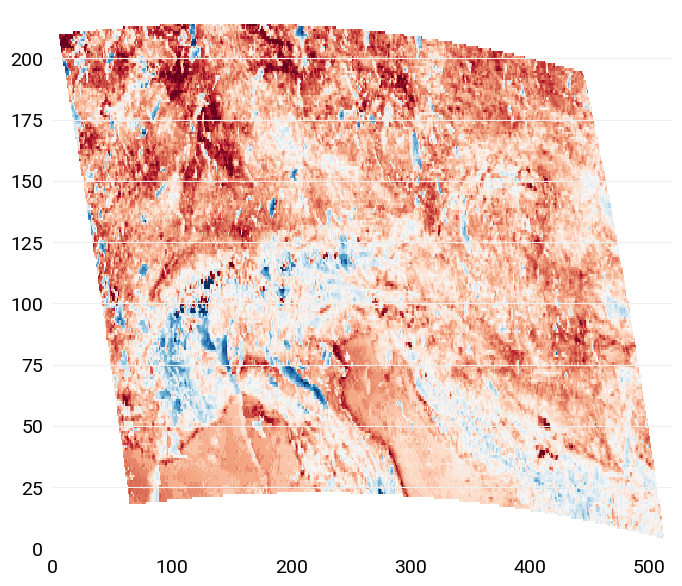

In [136]:
plt.pcolormesh(OmB_v12,vmin=-0.05,vmax=0.05,cmap='RdBu_r')

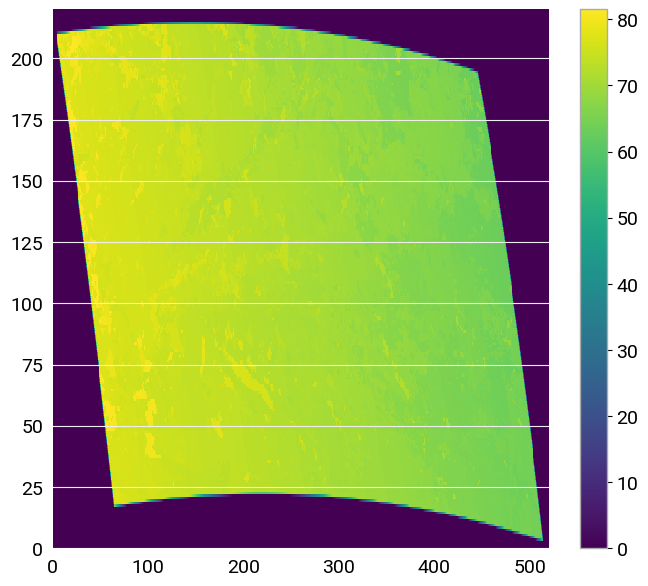

In [133]:
plt.pcolormesh(sza_06)
plt.colorbar()

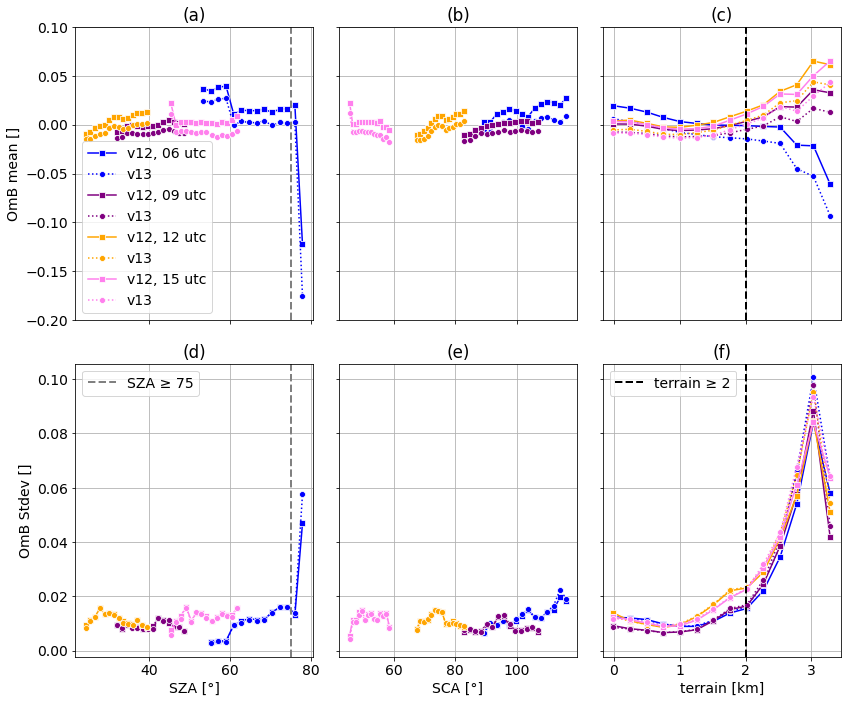

In [18]:
variables = ["SZA", "SCA", 'terrain'] # ['VZA', 'SZA', 'SCA', 'terrain']
units = ["[°]", "[°]", "[km]"]
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 10), sharey='row')
plt.rcParams.update({'font.size': 14})

# Collect legend handles and labels
handles, labels = [], []

# Loop through each set of DataFrames
for set_num, (df1, df2) in enumerate(zip(all_dfs[::2], all_dfs[1::2])):
    data_list1 = [bin_data(df1.copy(), var) for var in variables]
    data_list2 = [bin_data(df2.copy(), var) for var in variables]
    current_color = set_colors[set_num]

    for i, var in enumerate(variables):
        # Plot mean bias
        if i == 0:
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-', label=f'v12, {time_slice[set_num][:2]} utc')
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         color=current_color, marker='o', linestyle='dotted', label=f'v13')
            # Collect handles and labels (only for the first subplot)
            handles, labels = axes[0, i].get_legend_handles_labels()
        else:
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-')
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         color=current_color, marker='o', linestyle='dotted')

        axes[0, i].set_title(f'({chr(ord("a") + i)})')
        axes[0, i].set_ylabel('OmB mean []' if i == 0 else '')
        axes[0, i].set_xticklabels([])
        axes[0, i].set_xlabel('')
        axes[0, i].set_ylim(-0.2, 0.1)
        # Plot standard deviation
        sns.lineplot(ax=axes[1, i], x=var + '_bin', y='OmB_std', data=data_list1[i],
                     color=current_color, marker='s', linestyle='-')
        sns.lineplot(ax=axes[1, i], x=var + '_bin', y='OmB_std', data=data_list2[i],
                     color=current_color, marker='o', linestyle='dotted')
        axes[1, i].set_title(f'({chr(ord("a") + i + 3)})')
        axes[1, i].set_xlabel(var+" "+units[i])
        axes[1, i].set_ylabel('OmB Stdev []' if i == 0 else '')

for ax in axes.flatten():
    ax.grid(True)

# after drawing the vlines on the second row…
axes[0, 0].axvline(x=75, color='grey', linestyle='--', linewidth=2, label="SZA ≥ 75")
axes[0, 2].axvline(x=2,  color='black', linestyle='--', linewidth=2, label="terrain ≥ 2")
axes[1, 0].axvline(x=75, color='grey', linestyle='--', linewidth=2, label="SZA ≥ 75")
axes[1, 2].axvline(x=2,  color='black', linestyle='--', linewidth=2, label="terrain ≥ 2")

# now put legends on *those* axes:
axes[1, 0].legend(loc='upper left')
axes[1, 2].legend(loc='upper left')

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust top spacing to accommodate the legend
plt.show
plt.savefig('/home/km4c/to_ucloud/OmB_stats_angles_terrain.png')

In [76]:
tmp = np.take_lcs_v12_06.shape


(31, 220, 520)

In [ ]:
cs_v13_06_min   =  
